#Marketplace Brasil Olist - Quais fatores impulsionam ou comprometem o crescimento sustentável do marketplace da plataforma olist?

##Introdução


Esta análise tem como objetivo identificar os principais fatores que impulsionam ou comprometem o crescimento sustentável do marketplace no Brasil. Para isso, foram utilizados dados transacionais da própria operação, contemplando pedidos, produtos, clientes, vendedores, pagamentos e avaliações realizadas pelos consumidores entre 2016 e 2018.

A integração dessas bases permite uma visão abrangente do desempenho do negócio, incluindo evolução do volume de pedidos, distribuição do faturamento entre categorias, comportamento de pagamento e indicadores de satisfação do cliente. Com base nesses dados, buscamos identificar oportunidades de crescimento, riscos operacionais e pontos de atenção na gestão de parceiros.

A pergunta norteadora desta análise é: Quais fatores impulsionam ou comprometem o crescimento sustentável do marketplace? Ao final, serão apresentadas recomendações estratégicas para apoiar a tomada de decisão e orientar os próximos passos da empresa.

##Datasets Utilizados

https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

In [ ]:
rders = pd.read_csv('/content/olist_orders_dataset.csv')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
payments = pd.read_csv('/content/olist_order_payments_dataset.csv')
items = pd.read_csv('/content/olist_order_items_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
customers = pd.read_csv('/content/olist_customers_dataset.csv')
translation = pd.read_csv('/content/product_category_name_translation.csv')

##Análise

###GRÁFICO 1 — Crescimento do marketplace ao longo do tempo

O marketplace está crescendo consistentemente?

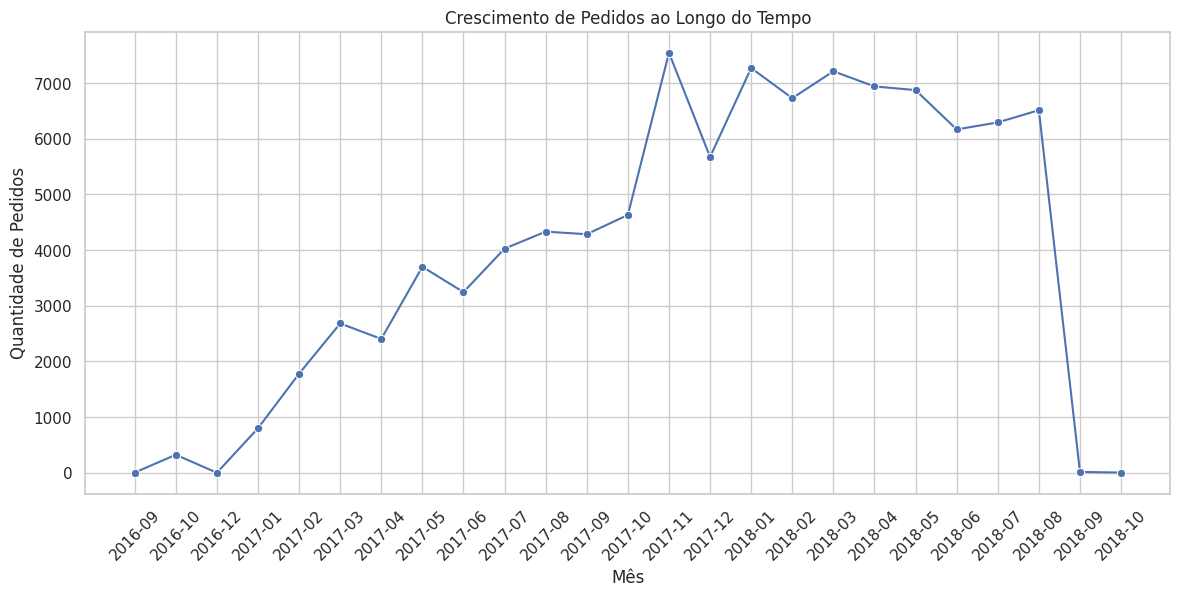

In [ ]:
rders['order_purchase_timestamp'] = pd.to_datetime(
    rders['order_purchase_timestamp']
)

rders['year_month'] = rders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = (
    rders.groupby('year_month')
    .size()
    .reset_index(name='total_orders')
)

monthly_orders['year_month'] = monthly_orders['year_month'].astype(str)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_orders,
    x='year_month',
    y='total_orders',
    marker='o'
)

plt.xticks(rotation=45)
plt.title('Crescimento de Pedidos ao Longo do Tempo')
plt.xlabel('Mês')
plt.ylabel('Quantidade de Pedidos')

plt.show()

O marketplace cresceu de forma consistente ao longo de 2017, com pico acentuado em Novembro, que é o mês da primeira parcela do 13º de muitos brasileiros e quando acontecem campanhas de "Black Friday" por todo o país, talvez sejam esses os fatores a serem considerados para este pico, mostrando que a plataforma conseguiu aproveitar bem a oportunidade.

Em 2018, o volume de pedidos se manteve alto e relativamente estável. Isso indica que o negócio conseguiu escalar e consolidar sua operação. Os últimos meses apresentam dados incompletos e não representam uma queda real nas vendas.

Embora a média do período seja de cerca de 5 mil pedidos mensais, os últimos meses da série atingem mais de 6.500 pedidos por mês, indicando que o crescimento da empresa acelerou significativamente ao longo do período analisado.

##Fatores de Impulsionamento do Negócio

###GRÁFICO 2 — Quais foram as categorias mais lucrativas?


Quais categorias impulsionam o faturamento? Onde está a receita da empresa?

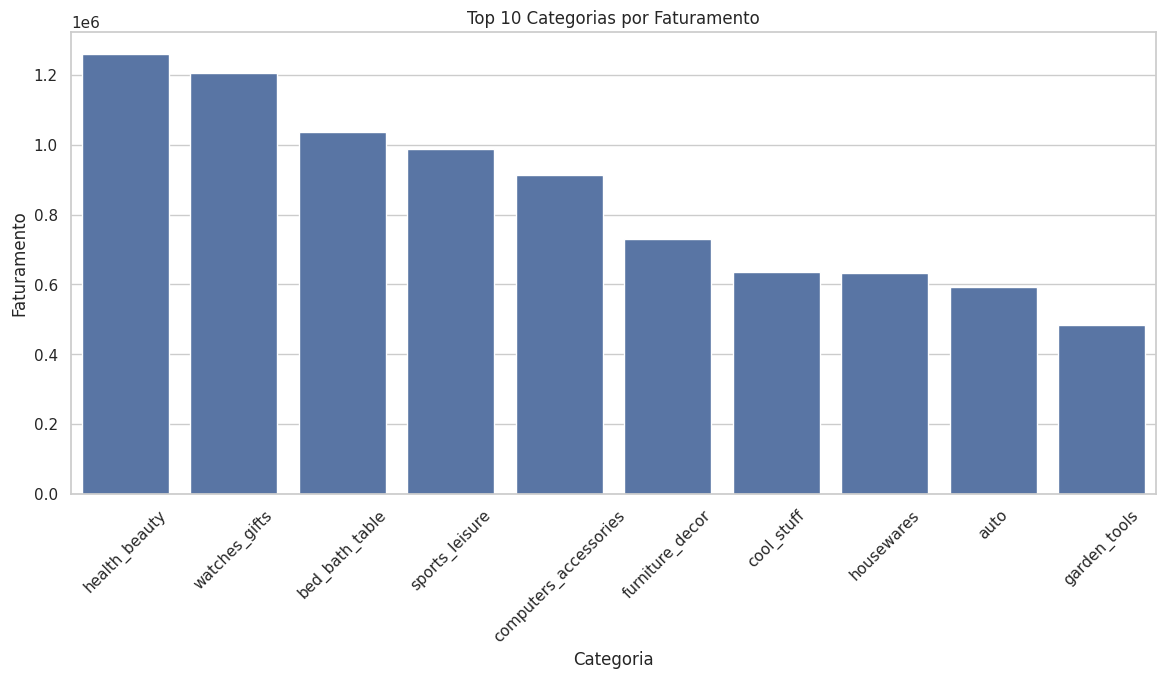

In [ ]:
items_products = items.merge(
    products,
    on='product_id'
)

items_products = items_products.merge(
    translation,
    on='product_category_name',
    how='left'
)

top_categories = (
    items_products.groupby('product_category_name_english')
    ['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=top_categories,
    x='product_category_name_english',
    y='price'
)

plt.xticks(rotation=45)

plt.title('Top 10 Categorias por Faturamento')
plt.xlabel('Categoria')
plt.ylabel('Faturamento')

plt.show()

Os dados indicam diversificação das fontes de receita do marketplace, com maior foco de rentabilidade nas categorias de health_beauty (beleza e saúde) e watches_gifts (relógios e presentes).

Do primeiro ao quinto negócio mais rentável existe uma diferença de 0.4M. Enquanto do primeiro ao segundo existe uma diferença de apenas 0.1M.

###GRÁFICO 3 — Quais os Estados com maior volume de pedidos?

Onde estão os principais mercados consumidores?

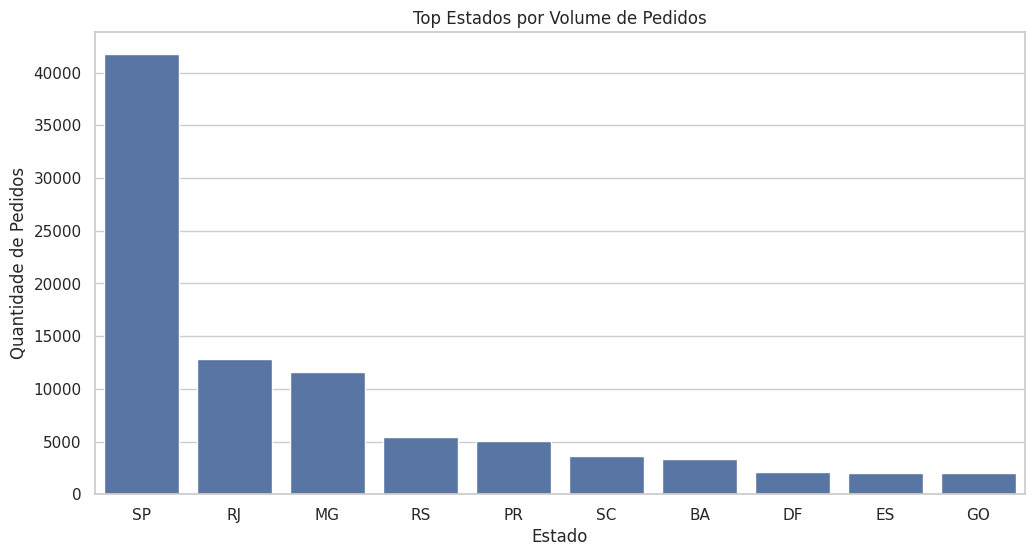

In [ ]:
orders_customers = rders.merge(
    customers,
    on='customer_id'
)

state_orders = (
    orders_customers.groupby('customer_state')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='total_orders')
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=state_orders,
    x='customer_state',
    y='total_orders'
)

plt.title('Top Estados por Volume de Pedidos')
plt.xlabel('Estado')
plt.ylabel('Quantidade de Pedidos')

plt.show()

São Paulo lidera com disparidade o número de pedidos realizados, seguidos por Rio de Janeiro e Minas Gerais, demonstrando que o Sudeste é a área mais rentável e a que merece maior atenção logística.

###GRÁFICO 4 — Formas de pagamento mais utilizadas


Como os clientes preferem pagar e qual é o perfil financeiro predominante?

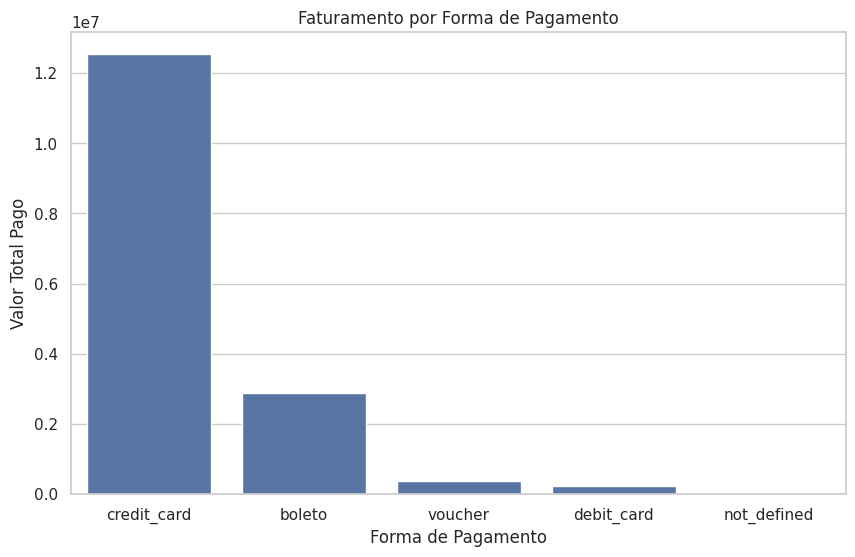

  payment_type  total_transactions  total_value  avg_installments
0  credit_card               76795  12542084.19          3.507155
1       boleto               19784   2869361.27          1.000000
2      voucher                5775    379436.87          1.000000
3   debit_card                1529    217989.79          1.000000
4  not_defined                   3         0.00          1.000000


In [ ]:
payment_summary = (
    payments.groupby('payment_type')
    .agg(
        total_transactions=('order_id', 'count'),
        total_value=('payment_value', 'sum'),
        avg_installments=('payment_installments', 'mean')
    )
    .sort_values('total_value', ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=payment_summary,
    x='payment_type',
    y='total_value'
)

plt.title('Faturamento por Forma de Pagamento')
plt.xlabel('Forma de Pagamento')
plt.ylabel('Valor Total Pago')

plt.show()

print(payment_summary)

O cartão de crédito é, de longe, a principal forma de pagamento do marketplace, concentrando a maior parte do faturamento. Isso indica forte preferência dos clientes por conveniência e parcelamento.

##Oportunidades de melhoria - Experiência dos Clientes

###GRÁFICO 5 — Sellers com pior avaliação média

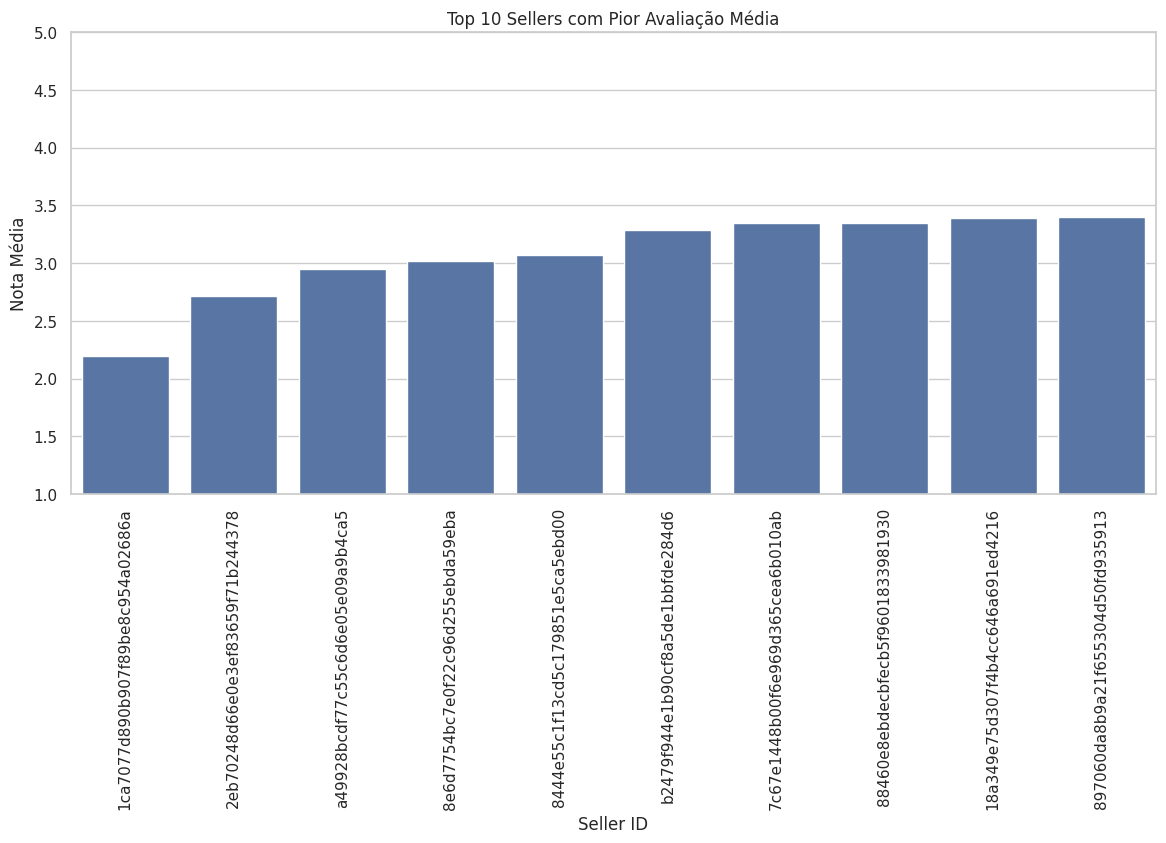

In [ ]:
seller_reviews = (
    items[['order_id', 'seller_id']]
    .merge(reviews[['order_id', 'review_score']], on='order_id')
)

seller_summary = (
    seller_reviews.groupby('seller_id')
    .agg(
        avg_review=('review_score', 'mean'),
        total_orders=('order_id', 'count')
    )
    .query('total_orders >= 100')
    .sort_values('avg_review')
    .head(10)
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=seller_summary,
    x='seller_id',
    y='avg_review'
)

plt.xticks(rotation=90)
plt.ylim(1, 5)

plt.title('Top 10 Sellers com Pior Avaliação Média')
plt.xlabel('Seller ID')
plt.ylabel('Nota Média')

plt.show()

Alguns sellers apresentam avaliações significativamente abaixo da média, com notas próximas de 2 estrelas. Esses resultados sugerem oportunidades de auditoria e melhoria na gestão de parceiros.

###GRÁFICO 6 — Categorias com pior avaliação média

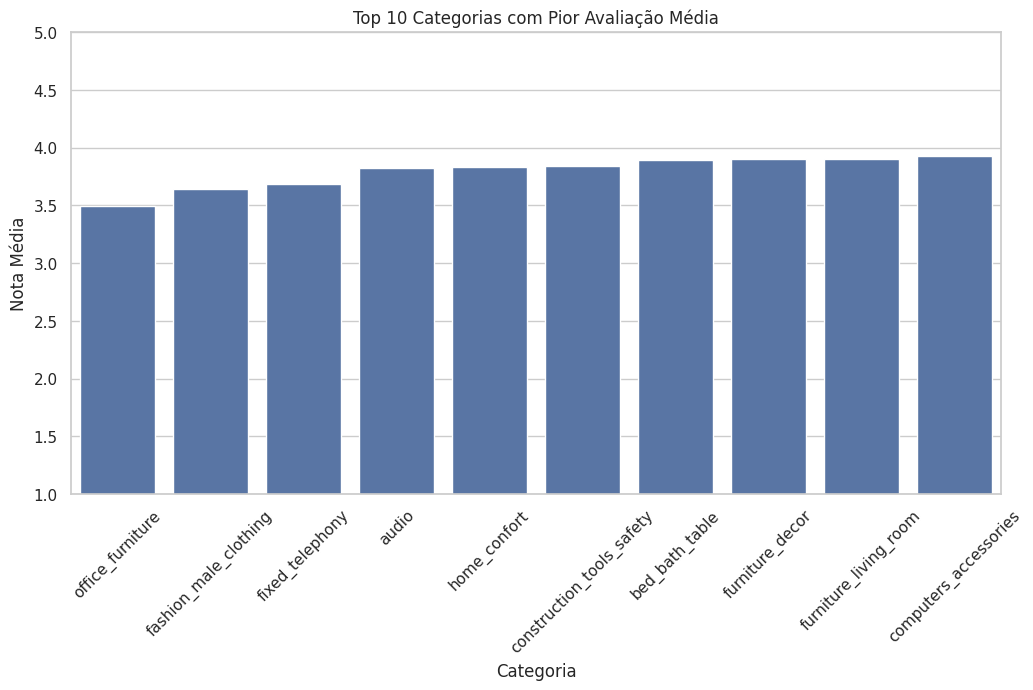

In [ ]:
category_reviews = (
    items
    .merge(products, on='product_id')
    .merge(translation, on='product_category_name', how='left')
    .merge(reviews[['order_id', 'review_score']], on='order_id')
)

category_summary = (
    category_reviews.groupby('product_category_name_english')
    .agg(
        avg_review=('review_score', 'mean'),
        total_orders=('order_id', 'count')
    )
    .query('total_orders >= 100')
    .sort_values('avg_review')
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=category_summary,
    x='product_category_name_english',
    y='avg_review'
)

plt.xticks(rotation=45)
plt.ylim(1, 5)

plt.title('Top 10 Categorias com Pior Avaliação Média')
plt.xlabel('Categoria')
plt.ylabel('Nota Média')

plt.show()

As categorias com pior avaliação incluem móveis, moda masculina, telefonia e eletrônicos. Isso indica que a insatisfação do cliente está distribuída entre diferentes segmentos, e não concentrada em um único tipo de produto.

Esses segmentos merecem atenção prioritária para identificar possíveis causas de insatisfação e oportunidades de melhoria.

##Conclusão

Os dados mostram que o marketplace apresentou forte crescimento ao longo de 2017 e mantiveram um alto volume de pedidos em 2018, evidenciando a consolidação e a escalabilidade do negócio.


O faturamento está relativamente bem distribuído entre diferentes categorias, com destaque para saúde e beleza, relógios e presentes e itens para o lar, o que reduz a dependência de um único segmento e torna a operação mais resiliente.

O cartão de crédito concentra a maior parte das transações, indicando forte preferência dos clientes por esse meio de pagamento e reforçando a importância de oferecer condições de parcelamento e conveniência.

Além disso, a análise identificou sellers e categorias com avaliações abaixo da média, revelando oportunidades de melhoria na gestão de parceiros e na experiência do cliente.

Em conjunto, os resultados sugerem que o marketplace possui bases sólidas para crescimento sustentável, apoiado por uma operação escalável, fontes de receita diversificadas e oportunidades claras de otimização operacional.

###Recomendações Estratégicas

Com base nas análises realizadas, recomenda-se priorizar ações que fortaleçam a escalabilidade do marketplace e aprimorem a experiência do cliente. As principais categorias de faturamento devem receber atenção especial, uma vez que representam importantes motores de receita e oferecem oportunidades para expansão comercial.

A concentração de vendas em São Paulo, Rio de Janeiro e Minas Gerais indica que a região Sudeste representa o principal mercado consumidor do marketplace. Recomenda-se fortalecer ações comerciais e logísticas nesses estados, além de utilizar os padrões de consumo observados como referência para expandir a operação em mercados com menor participação.

Considerando a predominância do cartão de crédito como principal meio de pagamento, a empresa pode avaliar parcerias com instituições financeiras ou o desenvolvimento de soluções próprias de crédito e parcelamento, com o objetivo de aumentar a conversão, fortalecer a fidelização e criar novas fontes de receita.

Também é recomendável monitorar de forma contínua os sellers com avaliações abaixo da média, oferecendo suporte, auditoria e planos de melhoria para reduzir riscos à reputação da plataforma. Da mesma forma, categorias com menor satisfação devem ser investigadas para identificar causas específicas, como qualidade do produto, descrição inadequada ou desafios operacionais. Em conjunto, essas ações podem aumentar a eficiência do marketplace, melhorar a satisfação do cliente e sustentar o crescimento do negócio no longo prazo.
